In [1]:
import matplotlib.pyplot as plt
import tensorflow as tf
import streamlit as st
import seaborn as sns
import pandas as pd
import numpy as np
import pickle

from sklearn.ensemble import BaggingRegressor, GradientBoostingRegressor, StackingRegressor, RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from catboost import CatBoostRegressor
from sklearn.linear_model import Ridge, ElasticNet

# Подготовка моделей

Выбран датасет об алмазах $\rightarrow$ выбраны модели для решения задачи регрессии, чтобы предсказать цену алмаза по характеристикам

**Модель ML1:** DecisionTreeRegressor<br>
**Модель ML2:** GradientBoostingRegressor<br>
**Модель ML3:** CatBoostRegressor<br>
**Модель ML4:** BaggingRegressor<br>
**Модель ML5:** StackingRegressor<br>
**Модель ML6:** Sequential (keras+tensorflow Neural Network)

## Загрузка данных

In [2]:
data = pd.read_csv('D:/Python/OmGTU/ML/data/post_diamonds.csv')

In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53794 entries, 0 to 53793
Data columns (total 10 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   carat    53794 non-null  float64
 1   cut      53794 non-null  int64  
 2   color    53794 non-null  int64  
 3   clarity  53794 non-null  int64  
 4   depth    53794 non-null  float64
 5   table    53794 non-null  float64
 6   price    53794 non-null  int64  
 7   x        53794 non-null  float64
 8   y        53794 non-null  float64
 9   z        53794 non-null  float64
dtypes: float64(6), int64(4)
memory usage: 4.1 MB


In [4]:
X = data.drop(columns='price')
X

,carat,cut,color,clarity,depth,table,x,y,z
0,0.23,0,1,6,61.5,55.0,3.95,3.98,2.43
1,0.21,1,1,5,59.8,61.0,3.89,3.84,2.31
2,0.23,3,1,3,56.9,65.0,4.05,4.07,2.31
3,0.29,1,5,4,62.4,58.0,4.20,4.23,2.63
4,0.31,3,6,6,63.3,58.0,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...
53789,0.72,0,0,5,60.8,57.0,5.75,5.76,3.50
53790,0.72,3,0,5,63.1,55.0,5.69,5.75,3.61
53791,0.70,2,0,5,62.8,60.0,5.66,5.68,3.56
53792,0.86,1,4,6,61.0,58.0,6.15,6.12,3.74


In [5]:
y = data['price']
y

0         326
1         326
2         327
3         334
4         335
         ... 
53789    2757
53790    2757
53791    2757
53792    2757
53793    2757
Name: price, Length: 53794, dtype: int64

## Инициализация моделей

In [13]:
model_tree = DecisionTreeRegressor(max_depth=12, min_samples_split=13, min_samples_leaf=8, random_state=42)

In [14]:
model_boost = GradientBoostingRegressor(**{'n_estimators': 333, 'learning_rate': 0.015750619803704784,
                                           'max_depth': 8, 'min_samples_split': 7, 'min_samples_leaf': 3,
                                           'subsample': 0.7276427960501565}, random_state=42)

In [15]:
model_catboost = CatBoostRegressor(**{'iterations': 1120, 'learning_rate': 0.0387592525723667,
                                      'depth': 6, 'l2_leaf_reg': 0.0006357456098930143, 'bagging_temperature': 0.03172310195167838,
                                      'random_strength': 3.7360878294978876, 'grow_policy': 'SymmetricTree'},
                                      task_type='CPU', thread_count=-1, random_state=42, verbose=0)

In [16]:
model_bagging = BaggingRegressor(**{'n_estimators': 82, 'max_samples': 0.7650220936235242, 'max_features': 0.9943533773759213},
                                 random_state=42, n_jobs=-1)

In [17]:
model_stacking = StackingRegressor(estimators=[('Ridge', Ridge(alpha=25.241424867460356, random_state=42, max_iter=2000)),
                                               ('GradientBoosting', GradientBoostingRegressor(**{'n_estimators': 333,
                                                                                                 'learning_rate': 0.015750619803704784,
                                                                                                 'max_depth': 8, 'min_samples_split': 7,
                                                                                                 'min_samples_leaf': 3, 'subsample': 0.7276427960501565},
                                                                                                 random_state=42)),
                                               ('RandomTree', RandomForestRegressor(**{'bootstrap': True, 'ccp_alpha': 0.0,
                                                                                       'criterion': 'squared_error', 'max_features': 1.0,
                                                                                       'min_impurity_decrease': 0.0, 'min_samples_leaf': 1,
                                                                                       'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0,
                                                                                       'n_estimators': 100, 'n_jobs': -1, 'oob_score': False,
                                                                                       'random_state': 50, 'verbose': 0, 'warm_start': False}))],
                                   final_estimator=ElasticNet(alpha=0.002183419021890954, l1_ratio=0.6572558012453984, random_state=42), n_jobs=-1)

In [18]:
model_neural = tf.keras.Sequential([
    tf.keras.layers.Dense(units=150, activation='relu'),
    tf.keras.layers.Dense(units=150, activation='relu'),
    tf.keras.layers.Dense(1, activation=None)
])

optimizer = tf.keras.optimizers.RMSprop(
    learning_rate=0.006761133009191603,
    rho=0.8797626552850855,
    momentum=0.21112666617269985
)

model_neural.compile(optimizer=optimizer, loss="mean_squared_error", metrics=["mae", "mse"])

## Обучение моделей

In [19]:
models = {'DecisionTree': model_tree,
          'GradientBoost': model_boost,
          'CatBoost': model_catboost,
          'Bagging': model_bagging,
          'Stacking': model_stacking,
          'NeuralNet': model_neural}

In [20]:
for name, model in models.items():
    if 'Neural' in name:
        model.fit(X, y, epochs=20)
    else:
        model.fit(X=X, y=y)
    print(f'The {name} model is trained')

The DecisionTree model is trained
The GradientBoost model is trained
The CatBoost model is trained
The Bagging model is trained


d:\Python\OmGTU\venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.442e+10, tolerance: 8.556e+07
  model = cd_fast.enet_coordinate_descent(


The Stacking model is trained
Epoch 1/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 6417994.0000 - mae: 1473.8315 - mse: 6417994.0000
Epoch 2/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1302074.0000 - mae: 604.9031 - mse: 1302074.0000
Epoch 3/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1485090.6250 - mae: 583.7811 - mse: 1485090.6250
Epoch 4/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1123381.6250 - mae: 551.5310 - mse: 1123381.6250
Epoch 5/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 996371.1875 - mae: 526.5294 - mse: 996371.1875
Epoch 6/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 935327.6250 - mae: 506.1956 - mse: 935327.6250
Epoch 7/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 839180.5000 - mae: 492.8751 - mse: 839180.5000
Epoch 8/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 731691.3750 - mae: 475.0896 - mse: 731691.3750
Epoch 9/20
1682/1682 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 630531.0625 - mae: 459.1086

# Сохранение (сериализация) готовых моделей

In [23]:
for name, model in models.items():
    if 'Cat' in name:
        model.save_model(f"dashboard/models/{name}.cbm")
    elif 'Neural' in name:
        model.save(f'dashboard/models/{name}.keras')
    else:
        with open(f"dashboard/models/{name}.pkl", "wb") as f:
            pickle.dump(model, f)

    print(f'The {name} model is saved')

The DecisionTree model is saved
The GradientBoost model is saved
The CatBoost model is saved
The Bagging model is saved
The Stacking model is saved
The NeuralNet model is saved


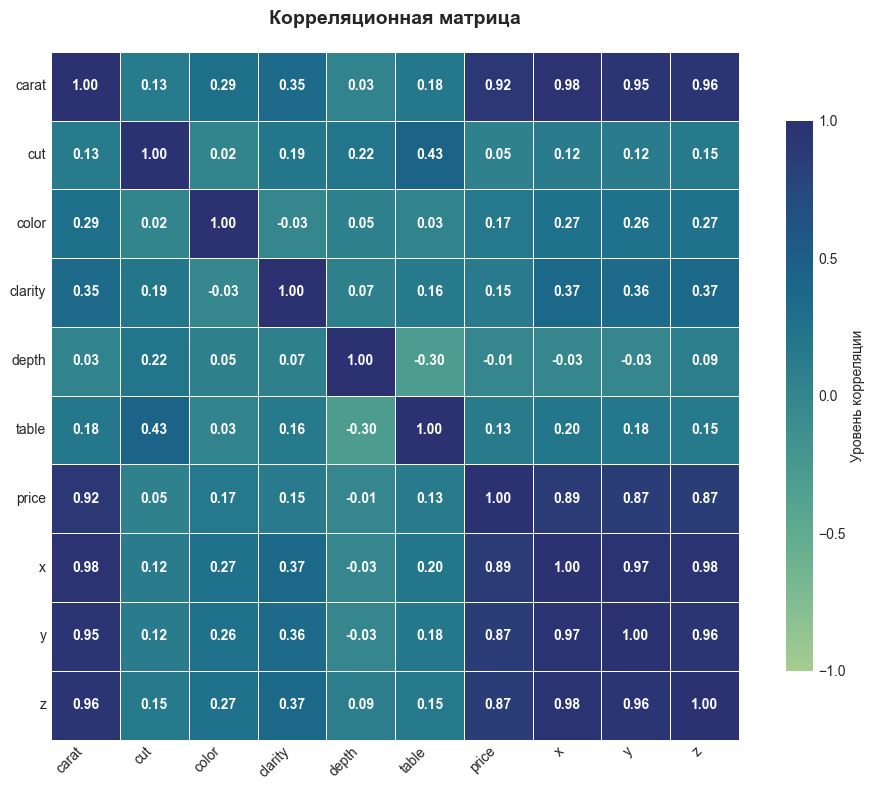

In [9]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

plt.figure(figsize=(10, 8))

heatmap = sns.heatmap(
    data.corr(),
    annot=True,
    fmt=".2f",
    cmap='crest',
    linewidths=0.5,
    linecolor='white',
    cbar_kws={
        'shrink': 0.8, 
        'label': 'Уровень корреляции',
        'ticks': [-1, -0.5, 0, 0.5, 1]
    },
    square=True,
    vmin=-1,
    vmax=1,
    annot_kws={
        'size': 10, 
        'weight': 'bold',
        'color': 'white'
    }
)

plt.title('Корреляционная матрица', pad=20, fontsize=14, weight='bold')
heatmap.set_xticklabels(
    heatmap.get_xticklabels(), 
    rotation=45, 
    ha='right',
    fontsize=10
)
heatmap.set_yticklabels(
    heatmap.get_yticklabels(), 
    rotation=0,
    fontsize=10
)

heatmap.grid(False)

plt.tight_layout()
plt.show()

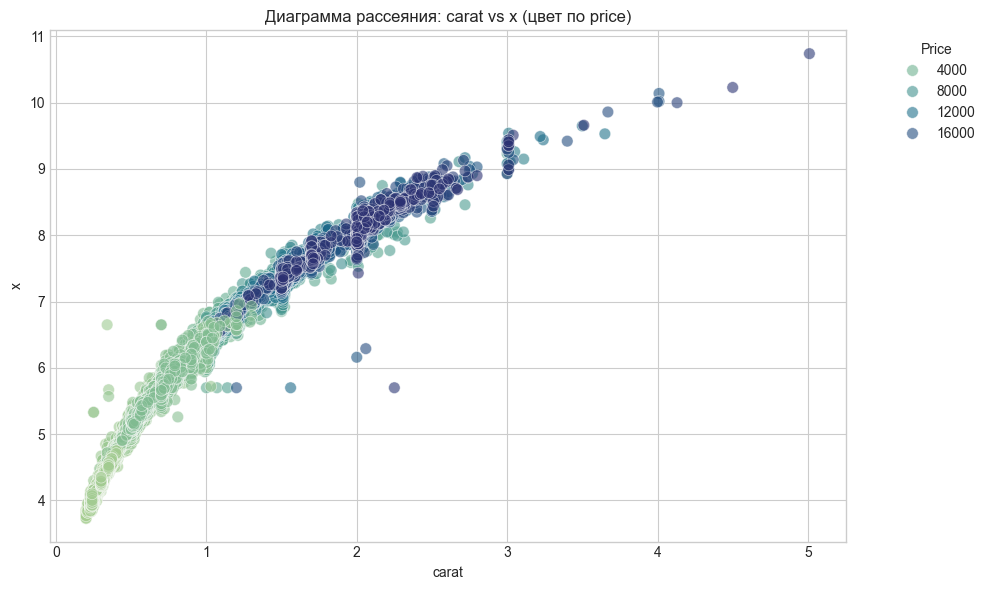

In [11]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

plt.figure(figsize=(10, 6))
scatter = sns.scatterplot(
    data=data,
    x='carat',
    y='x',
    hue='price',
    palette='crest',
    alpha=0.6,
    s=70,
    edgecolor='w',
    linewidth=0.5
)
plt.title('Диаграмма рассеяния: carat vs x (цвет по price)')
plt.legend(title='Price', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

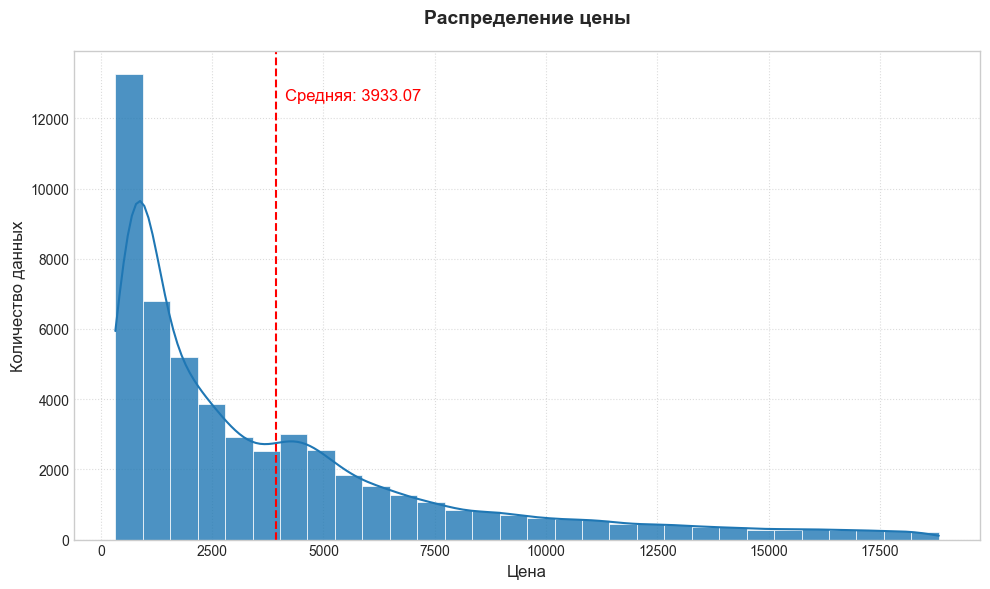

In [16]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

plt.figure(figsize=(10, 6))

hist = sns.histplot(
    data=data,
    x='price',
    bins=30,
    color='#1f77b4',
    edgecolor='white',
    linewidth=0.5,
    alpha=0.8,
    kde=True,
)

plt.title('Распределение цены', pad=20, fontsize=14, weight='bold')
plt.xlabel('Цена', fontsize=12)
plt.ylabel('Количество данных', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.7)

mean_price = data['price'].mean()
plt.axvline(mean_price, color='red', linestyle='--', linewidth=1.5)
plt.text(
    mean_price*1.05, plt.ylim()[1]*0.9, 
    f'Средняя: {mean_price:.2f}', 
    color='red',
    fontsize=12
)

plt.tight_layout()
plt.show()

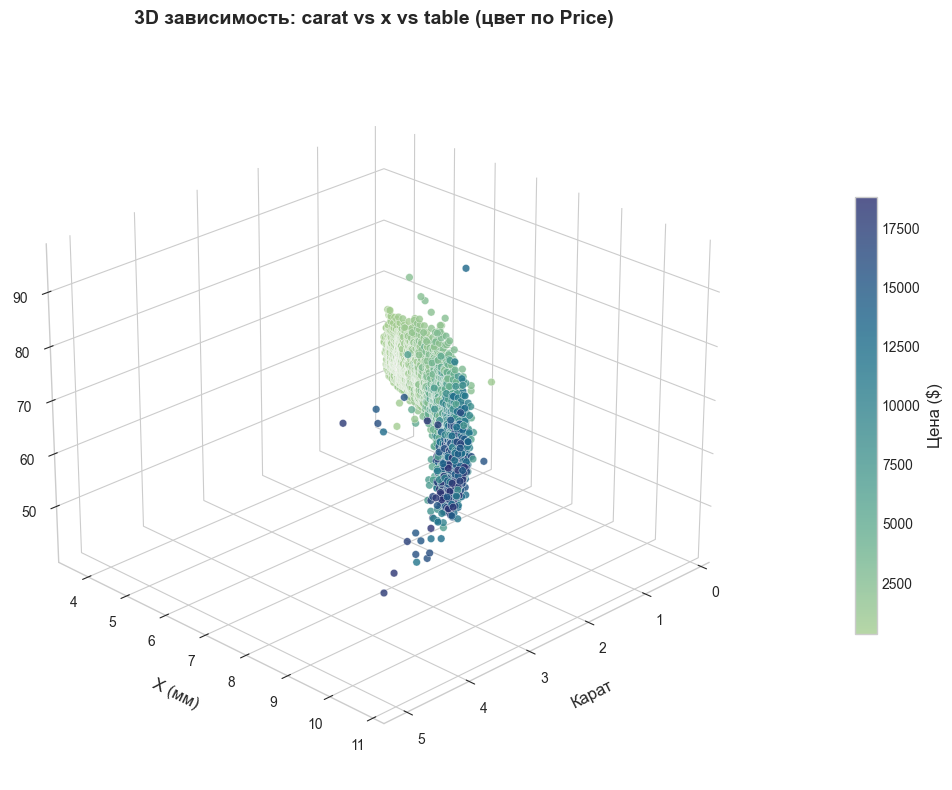

In [22]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.facecolor'] = 'white'

# Создаем 3D фигуру
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')

# Настраиваем 3D scatter plot
sc = ax.scatter3D(
    data['carat'], 
    data['x'], 
    data['table'],
    c=data['price'],
    cmap='crest',  # Та же палитра, что и в heatmap
    s=30,          # Увеличим размер точек
    alpha=0.8,
    edgecolor='w',
    linewidth=0.3
)

# Настройка осей и подписей
ax.set_xlabel('Карат', fontsize=12, labelpad=10)
ax.set_ylabel('X (мм)', fontsize=12, labelpad=10)
ax.set_zlabel('Таблица (%)', fontsize=12, labelpad=10)
ax.tick_params(axis='both', which='major', labelsize=10)

# Добавляем цветовую шкалу
cbar = fig.colorbar(sc, ax=ax, shrink=0.6, pad=0.1)
cbar.set_label('Цена ($)', fontsize=12)
cbar.ax.tick_params(labelsize=10)

# Настройка вида и освещения
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.xaxis.pane.set_edgecolor('white')
ax.yaxis.pane.set_edgecolor('white')
ax.zaxis.pane.set_edgecolor('white')
ax.grid(True, linestyle=':', alpha=0.5)

# Добавляем заголовок
plt.title('3D зависимость: carat vs x vs table (цвет по Price)', 
          fontsize=14, pad=20, weight='bold')

# Оптимальный угол обзора
ax.view_init(elev=25, azim=45)  # Можно настроить по вашему вкусу

plt.tight_layout()
plt.show()

..\..\venv\Scripts\Activate

streamlit run dashboard\app.py